In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("../data/raw/diabetic_data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [13]:
df.shape

(101766, 50)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [15]:
df['weight'].value_counts()

weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

In [16]:
df['weight'].value_counts()/101766 * 100

weight
?            96.858479
[75-100)      1.312816
[50-75)       0.881434
[100-125)     0.614154
[125-150)     0.142484
[25-50)       0.095317
[0-25)        0.047167
[150-175)     0.034393
[175-200)     0.010809
>200          0.002948
Name: count, dtype: float64

In [17]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [18]:
(df == '?').sum()/101766*100

encounter_id                 0.000000
patient_nbr                  0.000000
race                         2.233555
gender                       0.000000
age                          0.000000
weight                      96.858479
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                  39.557416
medical_specialty           49.082208
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.020636
diag_2                       0.351787
diag_3                       1.398306
number_diagnoses             0.000000
max_glu_serum                0.000000
A1Cresult                    0.000000
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

In [19]:
x = df.isnull() | (df == '?')
x.sum()/101766*100


encounter_id                 0.000000
patient_nbr                  0.000000
race                         2.233555
gender                       0.000000
age                          0.000000
weight                      96.858479
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                  39.557416
medical_specialty           49.082208
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.020636
diag_2                       0.351787
diag_3                       1.398306
number_diagnoses             0.000000
max_glu_serum               94.746772
A1Cresult                   83.277322
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

In [20]:
df['A1Cresult'].head(100)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
     ... 
95    NaN
96    NaN
97    NaN
98     >8
99    NaN
Name: A1Cresult, Length: 100, dtype: str

In [21]:
df['a1c_missing'] = df['A1Cresult'].isnull()
df.groupby(['a1c_missing', 'readmitted']).size()


a1c_missing  readmitted
False        <30            1676
             >30            5800
             NO             9542
True         <30            9681
             >30           29745
             NO            45322
dtype: int64

In [22]:
a1c_available = 1676/(5800+1676+9542)*100
print(a1c_available)
a1c_Missing = 9681/(9681+29745+45322)*100
print(a1c_Missing)

9.848395816194618
11.423278425449567


In [23]:
df['readmitted'].value_counts()/101766 * 100

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: count, dtype: float64

In [24]:
df['readmitted30_target'] = (df['readmitted'] == '<30').astype(int)
df['readmitted30_target'].value_counts()


readmitted30_target
0    90409
1    11357
Name: count, dtype: int64

In [25]:
# unique() → show me the unique values
# nunique() → number of unique values

df['patient_nbr'].nunique()

71518

In [26]:
df['patient_nbr'].value_counts()

patient_nbr
88785891     40
43140906     28
1660293      23
23199021     23
88227540     23
             ..
183087545     1
188574944     1
140199494     1
120975314     1
175429310     1
Name: count, Length: 71518, dtype: int64

In [27]:
df.select_dtypes(int).columns

Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'readmitted30_target'],
      dtype='str')

In [28]:
df['number_inpatient'].describe()

count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

<Axes: ylabel='number_inpatient'>

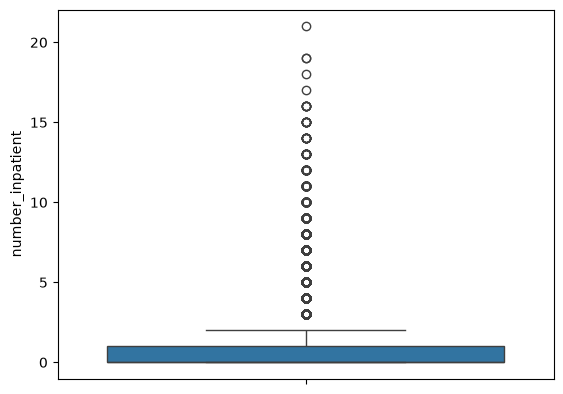

In [29]:
sns.boxplot(df['number_inpatient'])

In [30]:
df.groupby(['number_inpatient'])['readmitted30_target'].mean()*100


number_inpatient
0       8.437084
1      12.924543
2      17.433254
3      20.287306
4      23.612824
5      31.403941
6      34.583333
7      35.447761
8      44.370861
9      42.342342
10     42.622951
11     67.346939
12     50.000000
13     50.000000
14     40.000000
15    100.000000
16     33.333333
17    100.000000
18      0.000000
19     50.000000
21    100.000000
Name: readmitted30_target, dtype: float64

In [31]:
df.groupby(['number_inpatient']).size()

number_inpatient
0     67630
1     19521
2      7566
3      3411
4      1622
5       812
6       480
7       268
8       151
9       111
10       61
11       49
12       34
13       20
14       10
15        9
16        6
17        1
18        1
19        2
21        1
dtype: int64

<Axes: ylabel='number_emergency'>

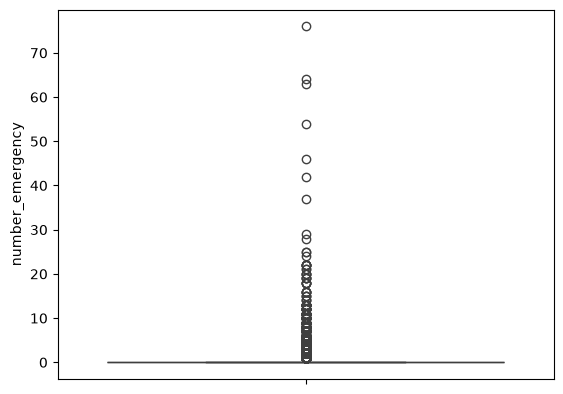

In [32]:
sns.boxplot(df['number_emergency'])

In [33]:
df.groupby(['number_emergency'])['readmitted30_target'].mean()*100


number_emergency
0      10.474315
1      14.354566
2      18.266405
3      20.275862
4      30.748663
5      24.479167
6      23.404255
7      26.027397
8      32.000000
9      36.363636
10     35.294118
11     21.739130
12     20.000000
13     33.333333
14      0.000000
15     33.333333
16     40.000000
18     20.000000
19     50.000000
20     50.000000
21     50.000000
22     50.000000
24      0.000000
25      0.000000
28    100.000000
29      0.000000
37      0.000000
42      0.000000
46      0.000000
54      0.000000
63      0.000000
64    100.000000
76      0.000000
Name: readmitted30_target, dtype: float64

In [34]:
df.groupby(['number_emergency']).size()

number_emergency
0     90383
1      7677
2      2042
3       725
4       374
5       192
6        94
7        73
8        50
9        33
10       34
11       23
12       10
13       12
14        3
15        3
16        5
18        5
19        4
20        4
21        2
22        6
24        1
25        2
28        1
29        1
37        1
42        1
46        1
54        1
63        1
64        1
76        1
dtype: int64

<Axes: ylabel='number_outpatient'>

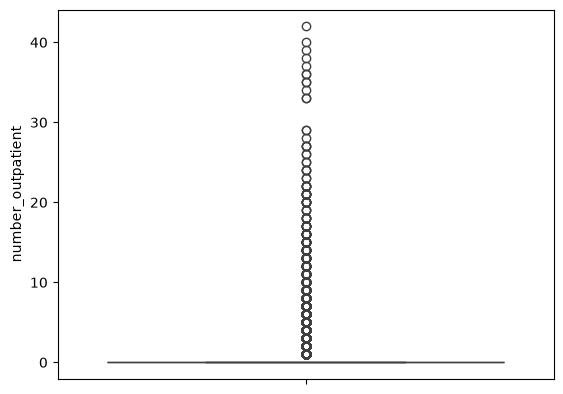

In [35]:
sns.boxplot(df['number_outpatient'])

In [36]:
df.groupby(df['number_outpatient'])['readmitted30_target'].mean()*100

number_outpatient
0      10.674256
1      13.923014
2      13.745131
3      12.291871
4      15.104641
5      11.819887
6      13.201320
7      15.483871
8       5.102041
9      15.662651
10      8.771930
11     14.285714
12     20.000000
13     19.354839
14     17.857143
15     10.000000
16      0.000000
17     12.500000
18      0.000000
19     33.333333
20      0.000000
21      0.000000
22     20.000000
23     50.000000
24      0.000000
25      0.000000
26      0.000000
27      0.000000
28      0.000000
29      0.000000
33      0.000000
34      0.000000
35      0.000000
36      0.000000
37      0.000000
38      0.000000
39      0.000000
40    100.000000
42      0.000000
Name: readmitted30_target, dtype: float64

In [37]:
df.groupby(['number_outpatient']).size()

number_outpatient
0     85027
1      8547
2      3594
3      2042
4      1099
5       533
6       303
7       155
8        98
9        83
10       57
11       42
12       30
13       31
14       28
15       20
16       15
17        8
18        5
19        3
20        7
21        7
22        5
23        2
24        3
25        2
26        2
27        3
28        1
29        2
33        2
34        1
35        2
36        2
37        1
38        1
39        1
40        1
42        1
dtype: int64

<Axes: ylabel='time_in_hospital'>

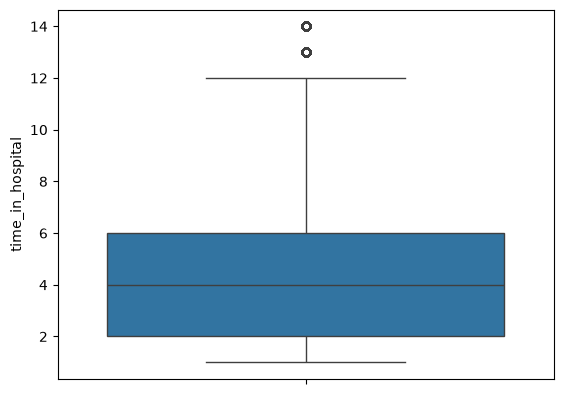

In [38]:
sns.boxplot(df['time_in_hospital'])

In [39]:
df.groupby(df['time_in_hospital'])['readmitted30_target'].mean()*100

time_in_hospital
1      8.178491
2      9.939619
3     10.666817
4     11.806952
5     12.030905
6     12.587876
7     12.834955
8     14.233660
9     13.724184
10    14.346712
11    10.512129
12    13.328729
13    12.314050
14    12.955854
Name: readmitted30_target, dtype: float64

In [40]:
df.groupby(['time_in_hospital']).size()

time_in_hospital
1     14208
2     17224
3     17756
4     13924
5      9966
6      7539
7      5859
8      4391
9      3002
10     2342
11     1855
12     1448
13     1210
14     1042
dtype: int64

<Axes: ylabel='num_medications'>

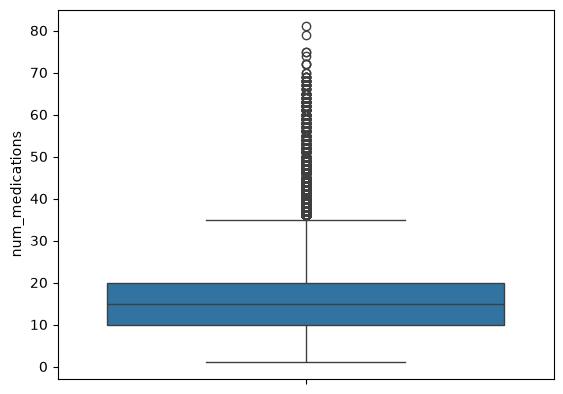

In [41]:
sns.boxplot(df['num_medications'])

In [42]:
result1 = df.groupby(df['num_medications'])['readmitted30_target'].mean()*100
result1.loc[10:30]

num_medications
10     9.970071
11    10.371009
12    10.776149
13    10.992442
14    10.758717
15    11.654006
16    11.491713
17    12.156942
18    12.182180
19    12.236390
20    13.112978
21    12.972136
22    13.423989
23    12.778236
24    13.750593
25    11.811441
26    12.810945
27    12.360335
28    11.922141
29    14.400000
30    11.660777
Name: readmitted30_target, dtype: float64

In [43]:
result2 = df.groupby(['num_medications']).size()
result2.loc[10:30]

num_medications
10    5346
11    5795
12    6004
13    6086
14    5707
15    5792
16    5430
17    4919
18    4523
19    4078
20    3691
21    3230
22    2868
23    2426
24    2109
25    1888
26    1608
27    1432
28    1233
29    1000
30     849
dtype: int64

<Axes: ylabel='number_diagnoses'>

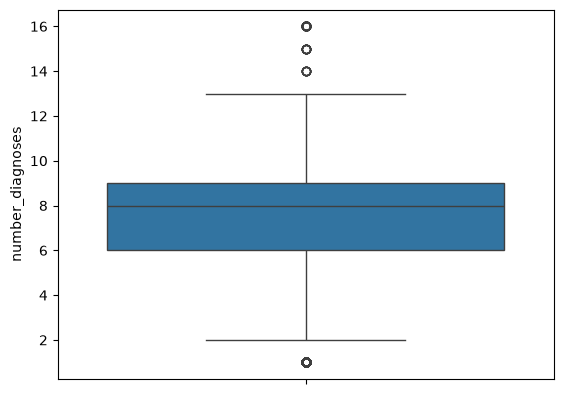

In [44]:
sns.boxplot(df['number_diagnoses'])

In [45]:
df.groupby(df['number_diagnoses'])['readmitted30_target'].mean()*100

number_diagnoses
1      5.936073
2      6.060606
3      7.372134
4      8.253567
5      9.154744
6     10.412361
7     10.766862
8     11.812359
9     12.380240
10    17.647059
11    27.272727
12    11.111111
13    18.750000
14    14.285714
15    20.000000
16     8.888889
Name: readmitted30_target, dtype: float64

In [46]:
df.groupby(df['number_diagnoses']).size()

number_diagnoses
1       219
2      1023
3      2835
4      5537
5     11393
6     10161
7     10393
8     10616
9     49474
10       17
11       11
12        9
13       16
14        7
15       10
16       45
dtype: int64

<Axes: ylabel='num_lab_procedures'>

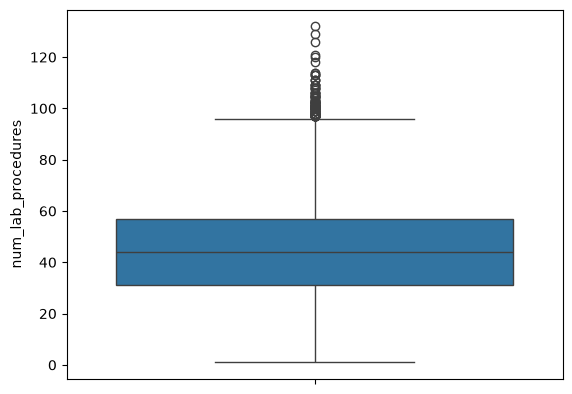

In [47]:
sns.boxplot(df['num_lab_procedures'])

In [48]:
df.groupby(df['num_lab_procedures'])['readmitted30_target'].mean()*100


num_lab_procedures
1        9.413965
2       11.444142
3        9.431138
4        6.349206
5        9.440559
          ...    
120      0.000000
121      0.000000
126      0.000000
129      0.000000
132    100.000000
Name: readmitted30_target, Length: 118, dtype: float64

In [49]:
df.groupby('readmitted30_target')['num_lab_procedures'].mean()

readmitted30_target
0    42.953644
1    44.226028
Name: num_lab_procedures, dtype: float64

In [50]:
df.groupby(df['num_lab_procedures']).size()

num_lab_procedures
1      3208
2      1101
3       668
4       378
5       286
       ... 
120       1
121       1
126       1
129       1
132       1
Length: 118, dtype: int64

In [51]:
df.groupby('readmitted30_target')['num_procedures'].mean()

readmitted30_target
0    1.347123
1    1.280884
Name: num_procedures, dtype: float64

In [52]:
df.groupby('readmitted30_target')['num_medications'].mean()

readmitted30_target
0    15.911137
1    16.903143
Name: num_medications, dtype: float64

<Axes: ylabel='num_procedures'>

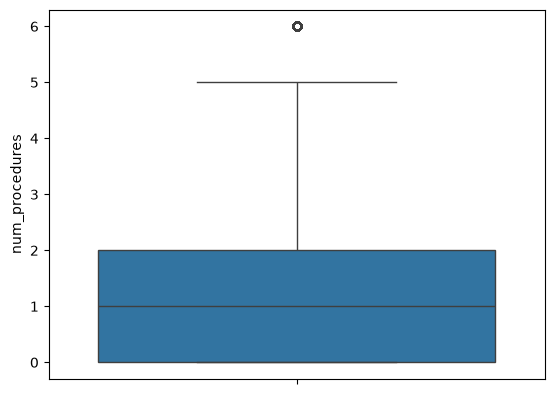

In [53]:
sns.boxplot(y=df['num_procedures'])

In [54]:
df['num_procedures'].value_counts().sort_index()

num_procedures
0    46652
1    20742
2    12717
3     9443
4     4180
5     3078
6     4954
Name: count, dtype: int64

<Axes: xlabel='readmitted30_target', ylabel='num_procedures'>

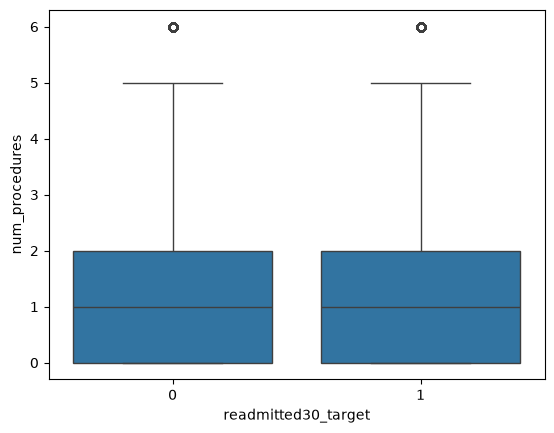

In [55]:
sns.boxplot(
    data=df,
    x='readmitted30_target',
    y='num_procedures'
)

In [56]:
df.groupby('readmitted30_target')['num_procedures'].mean()

readmitted30_target
0    1.347123
1    1.280884
Name: num_procedures, dtype: float64

In [57]:
df.groupby('readmitted30_target')['num_procedures'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
readmitted30_target,,,
0,90409,1.347123,1.0
1,11357,1.280884,1.0


In [58]:
df.groupby('num_procedures')['readmitted30_target'].mean() * 100

num_procedures
0    11.077767
1    12.207116
2    11.181883
3    10.685164
4    11.028708
5     9.421702
6     9.588212
Name: readmitted30_target, dtype: float64

In [59]:
df.select_dtypes(include='number').columns

Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'readmitted30_target'],
      dtype='str')

In [60]:
df.select_dtypes(exclude='number').columns

Index(['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty',
       'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'a1c_missing'],
      dtype='str')

In [61]:
result5 = df.nunique() 
result5[result5 > 50]

encounter_id          101766
patient_nbr            71518
medical_specialty         73
num_lab_procedures       118
num_medications           75
diag_1                   717
diag_2                   749
diag_3                   790
dtype: int64

In [62]:
df['age'].value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [63]:
df.groupby('readmitted30_target')['age'].value_counts()

readmitted30_target  age     
0                    [70-80)     22999
                     [60-70)     19981
                     [50-60)     15588
                     [80-90)     15119
                     [40-50)      8658
                     [30-40)      3351
                     [90-100)     2483
                     [20-30)      1421
                     [10-20)       651
                     [0-10)        158
1                    [70-80)      3069
                     [60-70)      2502
                     [80-90)      2078
                     [50-60)      1668
                     [40-50)      1027
                     [30-40)       424
                     [90-100)      310
                     [20-30)       236
                     [10-20)        40
                     [0-10)          3
Name: count, dtype: int64

In [64]:
df.groupby(df['age'])['readmitted30_target'].mean()*100

age
[0-10)       1.863354
[10-20)      5.788712
[20-30)     14.242607
[30-40)     11.231788
[40-50)     10.604027
[50-60)      9.666203
[60-70)     11.128408
[70-80)     11.773055
[80-90)     12.083503
[90-100)    11.099177
Name: readmitted30_target, dtype: float64

In [65]:
df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [66]:
df['race'].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [67]:
df.groupby('readmitted30_target')['gender'].value_counts()

readmitted30_target  gender         
0                    Female             48556
                     Male               41850
                     Unknown/Invalid        3
1                    Female              6152
                     Male                5205
Name: count, dtype: int64

In [68]:
df.groupby('readmitted30_target')['race'].value_counts()

readmitted30_target  race           
0                    Caucasian          67507
                     AfricanAmerican    17055
                     ?                   2085
                     Hispanic            1825
                     Other               1361
                     Asian                576
1                    Caucasian           8592
                     AfricanAmerican     2155
                     Hispanic             212
                     ?                    188
                     Other                145
                     Asian                 65
Name: count, dtype: int64

In [69]:
df.groupby(df['gender'])['readmitted30_target'].mean()*100

gender
Female             11.245156
Male               11.061524
Unknown/Invalid     0.000000
Name: readmitted30_target, dtype: float64

In [70]:
df.groupby(df['race'])['readmitted30_target'].mean()*100

race
?                   8.271007
AfricanAmerican    11.218116
Asian              10.140406
Caucasian          11.290556
Hispanic           10.407462
Other               9.628154
Name: readmitted30_target, dtype: float64

In [71]:
df['discharge_disposition_id'].value_counts()

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64

In [72]:
df.groupby(df['discharge_disposition_id'])['readmitted30_target'].mean()*100

discharge_disposition_id
1      9.300395
2     16.071429
3     14.662462
4     12.760736
5     20.861486
6     12.695706
7     14.446228
8     13.888889
9     42.857143
10     0.000000
11     0.000000
12    66.666667
13     4.761905
14     6.451613
15    44.444444
16     0.000000
17     0.000000
18    12.435654
19     0.000000
20     0.000000
22    27.696939
23     7.281553
24    14.583333
25     9.302326
27     0.000000
28    36.690647
Name: readmitted30_target, dtype: float64

In [73]:
df['admission_type_id'].value_counts()

admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

In [74]:
df.groupby(df['admission_type_id'])['readmitted30_target'].mean()*100

admission_type_id
1    11.522504
2    11.179654
3    10.392708
4    10.000000
5    10.344828
6    11.075411
7     0.000000
8     8.437500
Name: readmitted30_target, dtype: float64

In [75]:
df['A1Cresult'].value_counts()

A1Cresult
>8      8216
Norm    4990
>7      3812
Name: count, dtype: int64

In [76]:
df.groupby(df['A1Cresult'])['readmitted30_target'].mean()*100

A1Cresult
>7      10.047219
>8       9.870983
Norm     9.659319
Name: readmitted30_target, dtype: float64

In [77]:
df['max_glu_serum'].value_counts()

max_glu_serum
Norm    2597
>200    1485
>300    1264
Name: count, dtype: int64

In [78]:
df.groupby(df['max_glu_serum'])['readmitted30_target'].mean()*100

max_glu_serum
>200    12.457912
>300    14.319620
Norm    11.359261
Name: readmitted30_target, dtype: float64

In [79]:
df['diabetesMed'].value_counts()

diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64

In [80]:
df.groupby(df['diabetesMed'])['readmitted30_target'].mean()*100

diabetesMed
No      9.597060
Yes    11.626661
Name: readmitted30_target, dtype: float64

In [81]:
df['change'].value_counts()

change
No    54755
Ch    47011
Name: count, dtype: int64

In [82]:
df.groupby(df['change'])['readmitted30_target'].mean()*100

change
Ch    11.822765
No    10.590814
Name: readmitted30_target, dtype: float64

In [83]:
df['insulin'].value_counts()

insulin
No        47383
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

In [84]:
df.groupby(df['insulin'])['readmitted30_target'].mean()*100

insulin
Down      13.897528
No        10.037355
Steady    11.128400
Up        12.990456
Name: readmitted30_target, dtype: float64

In [85]:
df['metformin'].value_counts()

metformin
No        81778
Steady    18346
Up         1067
Down        575
Name: count, dtype: int64

In [86]:
df.groupby(df['metformin'])['readmitted30_target'].mean()*100

metformin
Down      12.000000
No        11.516545
Steady     9.713289
Up         8.247423
Name: readmitted30_target, dtype: float64

In [87]:
df['diag_1'].value_counts().head(10)

diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64

In [88]:
df.groupby(df['diag_1'])['readmitted30_target'].mean()*100

diag_1
10      0.000000
11      0.000000
110     0.000000
112    19.178082
114     0.000000
         ...    
V63    12.500000
V66     0.000000
V67     0.000000
V70     0.000000
V71     0.000000
Name: readmitted30_target, Length: 717, dtype: float64

In [89]:
df['diag_2'].value_counts().head(10)

diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
496    3305
599    3288
403    2823
414    2650
411    2566
Name: count, dtype: int64

In [90]:
df.groupby(df['diag_2'])['readmitted30_target'].mean()*100

diag_2
11      33.333333
110     25.000000
111      0.000000
112     13.930348
114    100.000000
          ...    
V69      0.000000
V70      0.000000
V72      0.000000
V85     13.017751
V86      0.000000
Name: readmitted30_target, Length: 749, dtype: float64

In [91]:
df['diag_3'].value_counts().head(10)

diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
414     3664
496     2605
403     2357
585     1992
272     1969
Name: count, dtype: int64

In [92]:
df.groupby(df['diag_3'])['readmitted30_target'].mean()*100

diag_3
11      50.000000
110     10.000000
111    100.000000
112     10.679612
115      0.000000
          ...    
V66      5.555556
V70      0.000000
V72     12.500000
V85      9.375000
V86      0.000000
Name: readmitted30_target, Length: 790, dtype: float64

In [93]:
#Data cleaning and preprocessing

In [94]:
df = df[~df['discharge_disposition_id'].isin([11, 13, 14, 19, 20, 21])]

In [95]:
# Keeps rows not equal to that value
df = df[df['gender'] != 'Unknown/Invalid']

In [96]:
# Keeps only the first occurrence for each ID
df = df.drop_duplicates(subset=['patient_nbr'], keep='first')

In [97]:
df.shape

(69987, 52)

In [98]:
df = df.drop(columns=['examide', 'citoglipton', 'weight', 'payer_code'])

In [99]:
df.shape

(69987, 48)

In [100]:
df['race'] = df['race'].replace('?', 'Unknown')
df['medical_specialty'] = df['medical_specialty'].replace('?', 'Unknown')

In [101]:
df['A1Cresult'] = df['A1Cresult'].replace('null', 'None')
df['max_glu_serum'] = df['max_glu_serum'].replace('null', 'None')

In [102]:
df['A1Cresult'] = df['A1Cresult'].fillna('None')
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')


In [103]:
def map_icd9(val):
    if pd.isna(val) or val == '?':
        return 'Other'
    
    val = str(val).strip()
    
    if val.startswith(('V', 'E')):
        return 'Other'
    
    if val.startswith('250'):
        return 'Diabetes'
    
    try:
        code = float(val)
    except ValueError:
        return 'Other'
        
    if (390 <= code <= 459) or code == 785:
        return 'Circulatory'
    elif (460 <= code <= 519) or code == 786:
        return 'Respiratory'
    elif (520 <= code <= 579) or code == 787:
        return 'Digestive'
    elif (580 <= code <= 629) or code == 788:
        return 'Genitourinary'
    elif 140 <= code <= 239:
        return 'Neoplasms'
    elif 710 <= code <= 739:
        return 'Musculoskeletal'
    elif 800 <= code <= 999:
        return 'Injury'
    else:
        return 'Other'


In [104]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[f"{col}_group"] = df[col].apply(map_icd9)

In [105]:
df['diag_1_group'].value_counts()

diag_1_group
Circulatory        21389
Other              12134
Respiratory         9491
Digestive           6488
Diabetes            5748
Injury              4694
Musculoskeletal     4064
Genitourinary       3441
Neoplasms           2538
Name: count, dtype: int64

In [106]:
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,a1c_missing,readmitted30_target,diag_1_group,diag_2_group,diag_3_group
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,NO,True,0,Diabetes,Other,Other
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,No,No,Ch,Yes,>30,True,0,Other,Diabetes,Other
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,Yes,NO,True,0,Other,Diabetes,Other
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,No,No,Ch,Yes,NO,True,0,Other,Diabetes,Circulatory
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,No,No,Ch,Yes,NO,True,0,Neoplasms,Neoplasms,Diabetes


In [107]:
#Feature Engineering

In [108]:
df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient'] 

In [109]:
df['total_visits']

0         0
1         0
2         3
3         0
4         0
         ..
101754    0
101755    1
101756    3
101758    1
101765    0
Name: total_visits, Length: 69987, dtype: int64

In [110]:
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

In [111]:
df['num_diabetes_meds'] = (df[med_cols] != 'No').sum(axis=1)


In [112]:
df['has_circulatory'] = ((df['diag_1_group'] == 'Circulatory') | (df['diag_2_group'] == 'Circulatory') | (df['diag_3_group'] == 'Circulatory').astype(int))
df['has_diabetes_diag'] = ((df['diag_1_group'] == 'Diabetes') | (df['diag_2_group'] == 'Diabetes') | (df['diag_3_group'] == 'Diabetes').astype(int))


In [113]:
df['has_circulatory'].value_counts()

has_circulatory
True     40739
False    29248
Name: count, dtype: int64

In [114]:
df['has_diabetes_diag'].value_counts()

has_diabetes_diag
False    42409
True     27578
Name: count, dtype: int64

In [115]:
df.groupby('total_visits')['readmitted30_target'].agg(['count', 'mean'])

,count,mean
total_visits,,
0,51781,0.079431
1,9538,0.105997
2,3959,0.122253
3,2061,0.128093
4,1112,0.145683
5,608,0.138158
6,324,0.191358
7,179,0.195531
8,117,0.136752


In [116]:
df.groupby('has_circulatory')['readmitted30_target'].mean() * 100

has_circulatory
False    8.369803
True     9.418493
Name: readmitted30_target, dtype: float64

In [117]:
df.groupby('num_diabetes_meds')['readmitted30_target'].mean() * 100

num_diabetes_meds
0     7.563680
1     9.717184
2     9.111529
3     8.973680
4     7.960199
5     0.000000
6    50.000000
Name: readmitted30_target, dtype: float64

In [118]:
age_dict = {
    '[0-10)': 5,
    '[10-20)': 15,
    '[20-30)': 25,
    '[30-40)': 35,
    '[40-50)': 45,
    '[50-60)': 55,
    '[60-70)': 65,
    '[70-80)': 75,
    '[80-90)': 85,
    '[90-100)': 95
}


In [119]:
df['age'] = df['age'].map(age_dict)


In [120]:
df['age'].value_counts()


age
75    17749
65    15688
55    12351
85    11110
45     6828
35     2692
95     1761
25     1121
15      534
5       153
Name: count, dtype: int64

In [121]:
cols_to_drop = [
    'encounter_id',
    'patient_nbr',
    'diag_1',
    'diag_2',
    'diag_3',
    'readmitted'
]

df = df.drop(columns=cols_to_drop)

In [122]:
df.shape

(69987, 49)

In [123]:
id_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

In [124]:
df[id_cols] = df[id_cols].astype(str)

In [125]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [130]:
df_encoded.shape

(69987, 211)

In [131]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,diabetesMed,a1c_missing,readmitted30_target,diag_1_group,diag_2_group,diag_3_group,total_visits,num_diabetes_meds,has_circulatory,has_diabetes_diag
0,Caucasian,Female,5,6,25,1,1,Pediatrics-Endocrinology,41,0,...,No,True,0,Diabetes,Other,Other,0,0,False,True
1,Caucasian,Female,15,1,1,7,3,Unknown,59,0,...,Yes,True,0,Other,Diabetes,Other,0,1,False,True
2,AfricanAmerican,Female,25,1,1,7,2,Unknown,11,5,...,Yes,True,0,Other,Diabetes,Other,3,1,False,True
3,Caucasian,Male,35,1,1,7,2,Unknown,44,1,...,Yes,True,0,Other,Diabetes,Circulatory,0,1,True,True
4,Caucasian,Male,45,1,1,7,1,Unknown,51,0,...,Yes,True,0,Neoplasms,Neoplasms,Diabetes,0,2,False,True


In [132]:
list(df_encoded.columns)

['age',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'a1c_missing',
 'readmitted30_target',
 'total_visits',
 'num_diabetes_meds',
 'has_circulatory',
 'has_diabetes_diag',
 'race_Asian',
 'race_Caucasian',
 'race_Hispanic',
 'race_Other',
 'race_Unknown',
 'gender_Male',
 'admission_type_id_2',
 'admission_type_id_3',
 'admission_type_id_4',
 'admission_type_id_5',
 'admission_type_id_6',
 'admission_type_id_7',
 'admission_type_id_8',
 'discharge_disposition_id_10',
 'discharge_disposition_id_12',
 'discharge_disposition_id_15',
 'discharge_disposition_id_16',
 'discharge_disposition_id_17',
 'discharge_disposition_id_18',
 'discharge_disposition_id_2',
 'discharge_disposition_id_22',
 'discharge_disposition_id_23',
 'discharge_disposition_id_24',
 'discharge_disposition_id_25',
 'discharge_disposition_id_27',
 'discharge_disposition_id_28',
 'discharge_disposit

In [133]:
[col for col in df_encoded.columns if 'diag' in col]


['number_diagnoses',
 'has_diabetes_diag',
 'diag_1_group_Diabetes',
 'diag_1_group_Digestive',
 'diag_1_group_Genitourinary',
 'diag_1_group_Injury',
 'diag_1_group_Musculoskeletal',
 'diag_1_group_Neoplasms',
 'diag_1_group_Other',
 'diag_1_group_Respiratory',
 'diag_2_group_Diabetes',
 'diag_2_group_Digestive',
 'diag_2_group_Genitourinary',
 'diag_2_group_Injury',
 'diag_2_group_Musculoskeletal',
 'diag_2_group_Neoplasms',
 'diag_2_group_Other',
 'diag_2_group_Respiratory',
 'diag_3_group_Diabetes',
 'diag_3_group_Digestive',
 'diag_3_group_Genitourinary',
 'diag_3_group_Injury',
 'diag_3_group_Musculoskeletal',
 'diag_3_group_Neoplasms',
 'diag_3_group_Other',
 'diag_3_group_Respiratory']

In [135]:
df_encoded[['diag_3_group_Injury', 'diag_3_group_Neoplasms']].head(10)


,diag_3_group_Injury,diag_3_group_Neoplasms
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
5,False,False
6,False,False
7,False,False
8,False,False
9,False,False


In [ ]:
#Train test split

In [136]:
X = df_encoded.drop(columns = ['readmitted30_target'])

In [137]:
y = df_encoded['readmitted30_target']

In [ ]:
#Stratified Train-Test Split (80% Train, 20% Test)

In [140]:
from sklearn.model_selection import train_test_split

In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [142]:
print(X_train.shape)

(55989, 210)


In [143]:
print(X_test.shape)

(13998, 210)


In [ ]:
#Building baseline model development

In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
# 1. Create a Pipeline with StandardScaler + LogisticRegression
# We use class_weight='balanced' to handle the 8.8% class imbalance

In [146]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier',
LogisticRegression(class_weight='balanced',
max_iter=1000, random_state=42))
])

In [147]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](210,)","['age','time_in_hospital','num_lab_procedures',..., 'diag_3_group_Neoplasms','diag_3_group_Other','diag_3_group_Respiratory']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,210
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [150]:
y_pred_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = lr_pipeline.predict(X_test)

In [153]:
print("roc_auc_score:", roc_auc_score(y_test, y_pred_prob_lr))

roc_auc_score: 0.6521247593805902


In [154]:
print("classification_report", classification_report(y_test, y_pred_lr))

classification_report               precision    recall  f1-score   support

           0       0.94      0.68      0.79     12741
           1       0.14      0.54      0.22      1257

    accuracy                           0.66     13998
   macro avg       0.54      0.61      0.51     13998
weighted avg       0.87      0.66      0.74     13998



In [155]:
from sklearn.ensemble import RandomForestClassifier

In [157]:
#Intialize the random forest
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [158]:
#Train on training data
rf_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [159]:
#Predict on Training data
y_pred_prob_lr = rf_model.predict_proba(X_test)[:, 1]
y_pred = rf_model.predict(X_test)

In [160]:
#Evaluation metrics
print("===Random Forest Baseline results===")
print("Roc_Auc_Score", roc_auc_score(y_test, y_pred_prob_lr))
print("classification_report", classification_report(y_test, y_pred))

===Random Forest Baseline results===
Roc_Auc_Score 0.6503235597005564
classification_report               precision    recall  f1-score   support

           0       0.94      0.70      0.80     12741
           1       0.15      0.52      0.23      1257

    accuracy                           0.68     13998
   macro avg       0.54      0.61      0.51     13998
weighted avg       0.87      0.68      0.75     13998



In [162]:
import xgboost as xgb

In [ ]:
# 1. Calculate class imbalance weight: (negative count / positive count)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [164]:
# 2. Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators = 150,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

In [165]:
#Train on training data
xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [167]:
#Predict on test data
y_pred_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

In [168]:
#classification report
print('=== XGBoost Results ===')
print('roc_auc_score', roc_auc_score(y_test, y_pred_prob_xgb))
print('classification report', classification_report(y_test, y_pred_xgb))

=== XGBoost Results ===
roc_auc_score 0.653975255249045
classification report               precision    recall  f1-score   support

           0       0.94      0.70      0.80     12741
           1       0.14      0.52      0.23      1257

    accuracy                           0.68     13998
   macro avg       0.54      0.61      0.51     13998
weighted avg       0.86      0.68      0.75     13998



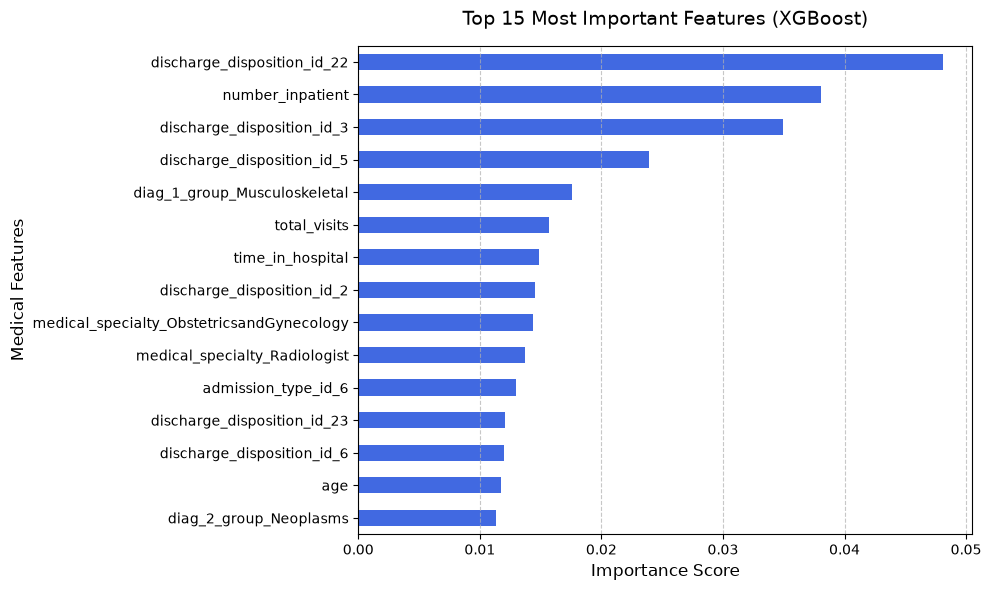

In [169]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract feature importances and pair them with column names
feature_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)

# 2. Get the Top 15 highest-scoring features
top_15 = feature_importance.nlargest(15)

# 3. Plot as a horizontal bar chart
plt.figure(figsize=(10, 6))
top_15.sort_values(ascending=True).plot(kind='barh', color='royalblue')

# 4. Add titles and labels
plt.title('Top 15 Most Important Features (XGBoost)', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Medical Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
